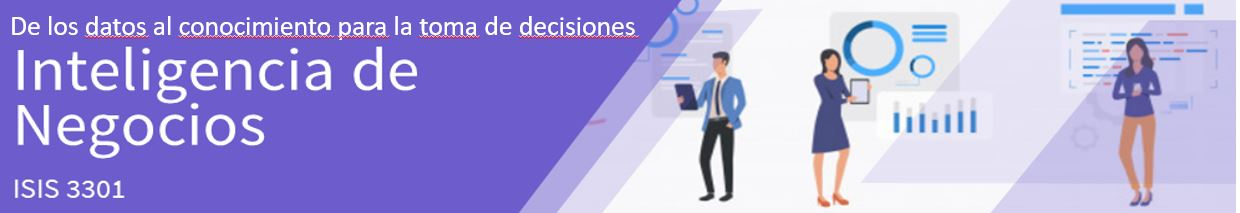

## Tarea de agrupación

El objetivo de este notebook es mostrar cómo resolver una tarea de **agrupación (clustering)** utilizando la librería **scikit-learn**.

En este laboratorio aplicamos algoritmos de agrupación no supervisada al caso de *SenecaféAlpes*, una empresa dedicada a la producción de café de alta calidad. Usando un conjunto de datos con atributos de los granos de café, el objetivo es identificar patrones que apoyen los procesos de **control de calidad** y **optimización de mercado**. Siguiendo la metodología **CRISP-ML**, el proyecto incluye una sección de **preparación de datos**, modelamiento con **K-Means**, **DBSCAN** y **_____**, además de validación cuantitativa y cualitativa. Finalmente, se presentan conclusiones y recomendaciones orientadas al negocio, útiles para la organización.



## Caso
SenecaféAlpes es una compañía dedicada a la producción, procesamiento y comercialización de café de alta calidad. Uno de sus principales retos consiste en garantizar la uniformidad y trazabilidad de sus granos, ya que la heterogeneidad en tamaño, forma y estructura puede afectar tanto los procesos de tostión como la percepción de calidad del consumidor final. Para enfrentar este desafío, la empresa implementó un sistema de visión por computadora que capturó imágenes de granos correspondientes a siete variedades registradas de café. Tras un proceso de segmentación y extracción de características, se construyó un conjunto de datos con 16 atributos para cada grano.

A partir de este insumo, SenecaféAlpes ha decidido emprender un proyecto de analítica de datos cuyo objetivo es la aplicación de técnicas de agrupación para identificar patrones morfológicos que permitan caracterizar las distintas variedades de café. La expectativa de la empresa es que los resultados de este estudio generen beneficios en tres dimensiones principales: (i) control de calidad, mediante la caracterización morfológica de los granos para estandarizar procesos de selección y clasificación; (ii) optimización del mercado, a partir de la comprensión de las agrupaciones naturales de las variedades y su aprovechamiento en el diseño de nuevas mezclas con valor agregado; (iii) innovación en trazabilidad, estableciendo las bases para sistemas automáticos de identificación que reduzcan la dependencia de evaluaciones manuales.
Para llevar a cabo este proyecto, la empresa nos ha contratado como científicos de datos, proporcionándonos no solo el conjunto de datos generado, sino también la documentación correspondiente a la descripción detallada de cada atributo (diccionario).

- [Datos de entrenamiento](Datos_SenecaféAlpes.csv)
- [Diccionario de datos](Diccionario_SenecaféAlpes.xlsx)


## 1. Carga de librerías necesarias para implementación

In [1]:
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()  # for plot styling

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D # for 3D plots


## 2. Cargar los datos

In [29]:
# Se cargan los datos. 
df=pd.read_csv('data/Datos_SenecaféAlpes.csv', sep=';', encoding = "UTF-8")

## 3. Entendimiento de los datos 

### 3.1. Perfilamiento de datos

In [ ]:
df.shape

(14291, 19)

In [35]:
df.head()

,ID,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,RelacionAspecto,Excentricidad,AreaConvexa,DiametroEquivalente,Medida,Solidez,Redondez,Compacidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4,DefectoVisible,MétodoSecado
0,G006149,50836,923618.0,358.515147,181.388899,alargado,NaN,NaN,254.413847,0.804762,0.983840,0.748853,0.709632,0.007052,0.001103,0.503578,0.995321,Normal,Lavado
1,G007234,62764,1003767.0,409.207082,198.330199,Alargado,NaN,64158.0,282.689948,0.703995,0.978272,0.782807,0.690824,0.006520,0.000916,0.477237,0.984666,NaN,Natural
2,G007054,59965,994266.0,389.088529,197.967275,Alargado,0.860886,60910.0,276.314692,0.661581,0.984485,0.762259,0.710159,0.006489,0.001018,0.504326,0.991211,Normal,Natural
3,G006619,55035,917.6,379.346822,185.390577,Alargado,0.872446,55591.0,NaN,0.799695,0.989998,0.821376,0.697811,0.006893,0.001008,0.486941,0.996380,Normal,Lavado
4,G013353,39324,737773.0,262.520242,191.176858,Alargado,0.685326,39758.0,223.760747,0.775392,0.989084,0.907867,0.852356,0.006676,0.002174,0.726511,0.997630,Normal,Lavado


In [32]:
# Revisar las características de los datos: completitud y tipo de dato
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14291 entries, 0 to 14290
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   14291 non-null  object 
 1   Area                 14291 non-null  int64  
 2   Perimetro            13054 non-null  float64
 3   LongitudEjeMayor     13890 non-null  float64
 4   LongitudEjeMenor     14291 non-null  float64
 5   RelacionAspecto      13825 non-null  object 
 6   Excentricidad        13687 non-null  float64
 7   AreaConvexa          12868 non-null  float64
 8   DiametroEquivalente  12368 non-null  float64
 9   Medida               14291 non-null  float64
 10  Solidez              11985 non-null  float64
 11  Redondez             12228 non-null  float64
 12  Compacidad           13641 non-null  float64
 13  FactorForma1         13172 non-null  float64
 14  FactorForma2         13185 non-null  float64
 15  FactorForma3         13813 non-null 

In [36]:
# Resumen de los estadisticos de las variables numéricas
df.describe()

,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,Excentricidad,AreaConvexa,DiametroEquivalente,Medida,Solidez,Redondez,Compacidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4
count,14291.000000,1.305400e+04,13890.000000,14291.000000,13687.000000,12868.000000,12368.000000,14291.000000,11985.000000,12228.000000,13641.000000,13172.000000,13185.000000,13813.000000,13132.000000
mean,53055.408999,7.729870e+05,319.985592,202.178613,0.749977,53575.397809,253.001741,0.749844,0.986774,0.873080,0.799242,0.006560,0.001712,0.643183,0.994292
std,29396.080372,3.266493e+05,86.378452,45.494541,0.099438,29566.387814,60.542330,0.050774,0.025947,0.063237,0.067643,0.001164,0.000601,0.100857,0.039081
min,-62716.000000,-1.012143e+06,-421.444657,-200.838672,-0.835004,-78423.000000,-448.402605,-0.798706,-0.989042,-0.896861,-0.843901,-0.007982,-0.002673,-0.683269,-0.998527
25%,36338.000000,6.768608e+05,253.319858,175.881052,0.715144,36720.000000,215.302463,0.718767,0.985597,0.832824,0.762127,0.005903,0.001151,0.581047,0.993663
50%,44660.000000,7.720345e+05,296.682345,192.437870,0.764392,45107.500000,238.579492,0.760232,0.988279,0.883353,0.800994,0.006645,0.001691,0.641648,0.996377
75%,61311.000000,9.554098e+05,376.548109,216.847844,0.810441,62109.250000,279.672481,0.786942,0.989991,0.916803,0.834405,0.007273,0.002169,0.696366,0.997889
max,254616.000000,1.921685e+06,738.860154,460.198497,0.911423,251082.000000,569.374358,0.866195,0.994378,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [37]:
# Separar variables numericas y categoricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Valores Numericos: ", num_cols)
print("Valores Categoricos: ", cat_cols)

Valores Numericos:  ['Area', 'Perimetro', 'LongitudEjeMayor', 'LongitudEjeMenor', 'Excentricidad', 'AreaConvexa', 'DiametroEquivalente', 'Medida', 'Solidez', 'Redondez', 'Compacidad', 'FactorForma1', 'FactorForma2', 'FactorForma3', 'FactorForma4']
Valores Categoricos:  ['ID', 'RelacionAspecto', 'DefectoVisible', 'MétodoSecado']


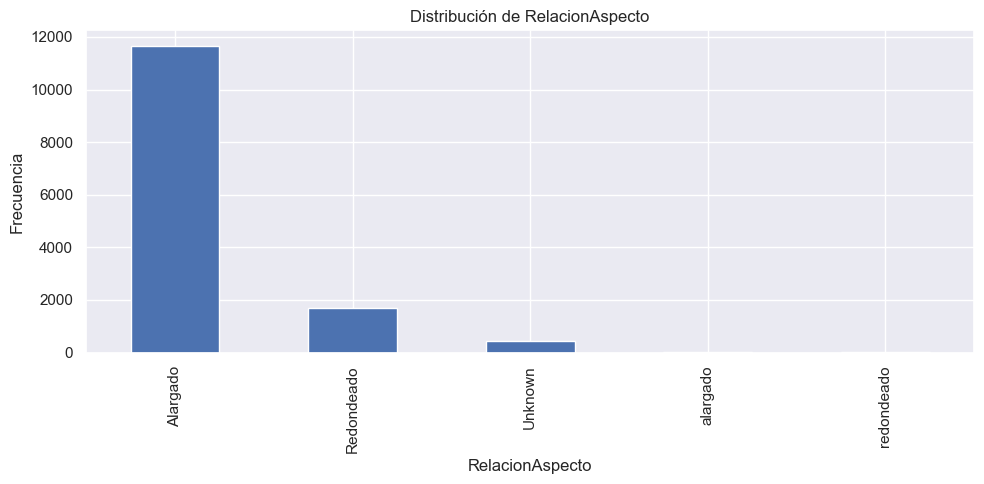

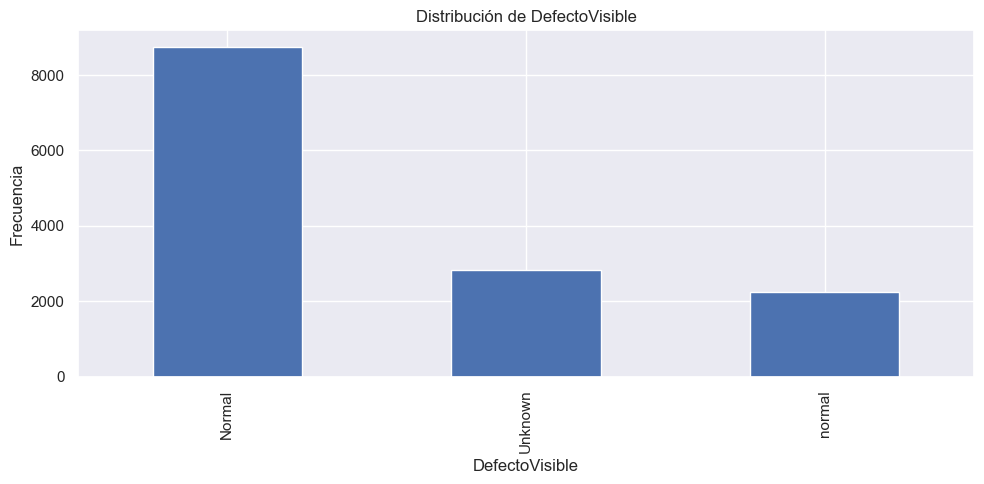

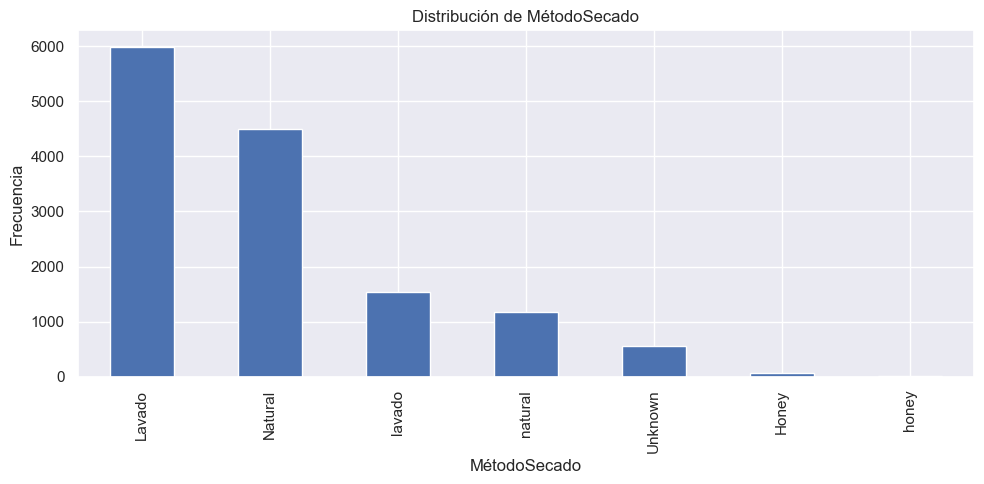

In [70]:
for col in cat_cols:
    if df[col].nunique() <= 20:
        plt.figure(figsize=(10, 5))
        df[col].value_counts().plot(kind="bar")
        plt.title(f"Distribución de {col}")
        plt.xlabel(col)
        plt.ylabel("Frecuencia")
        plt.tight_layout()
        plt.show()

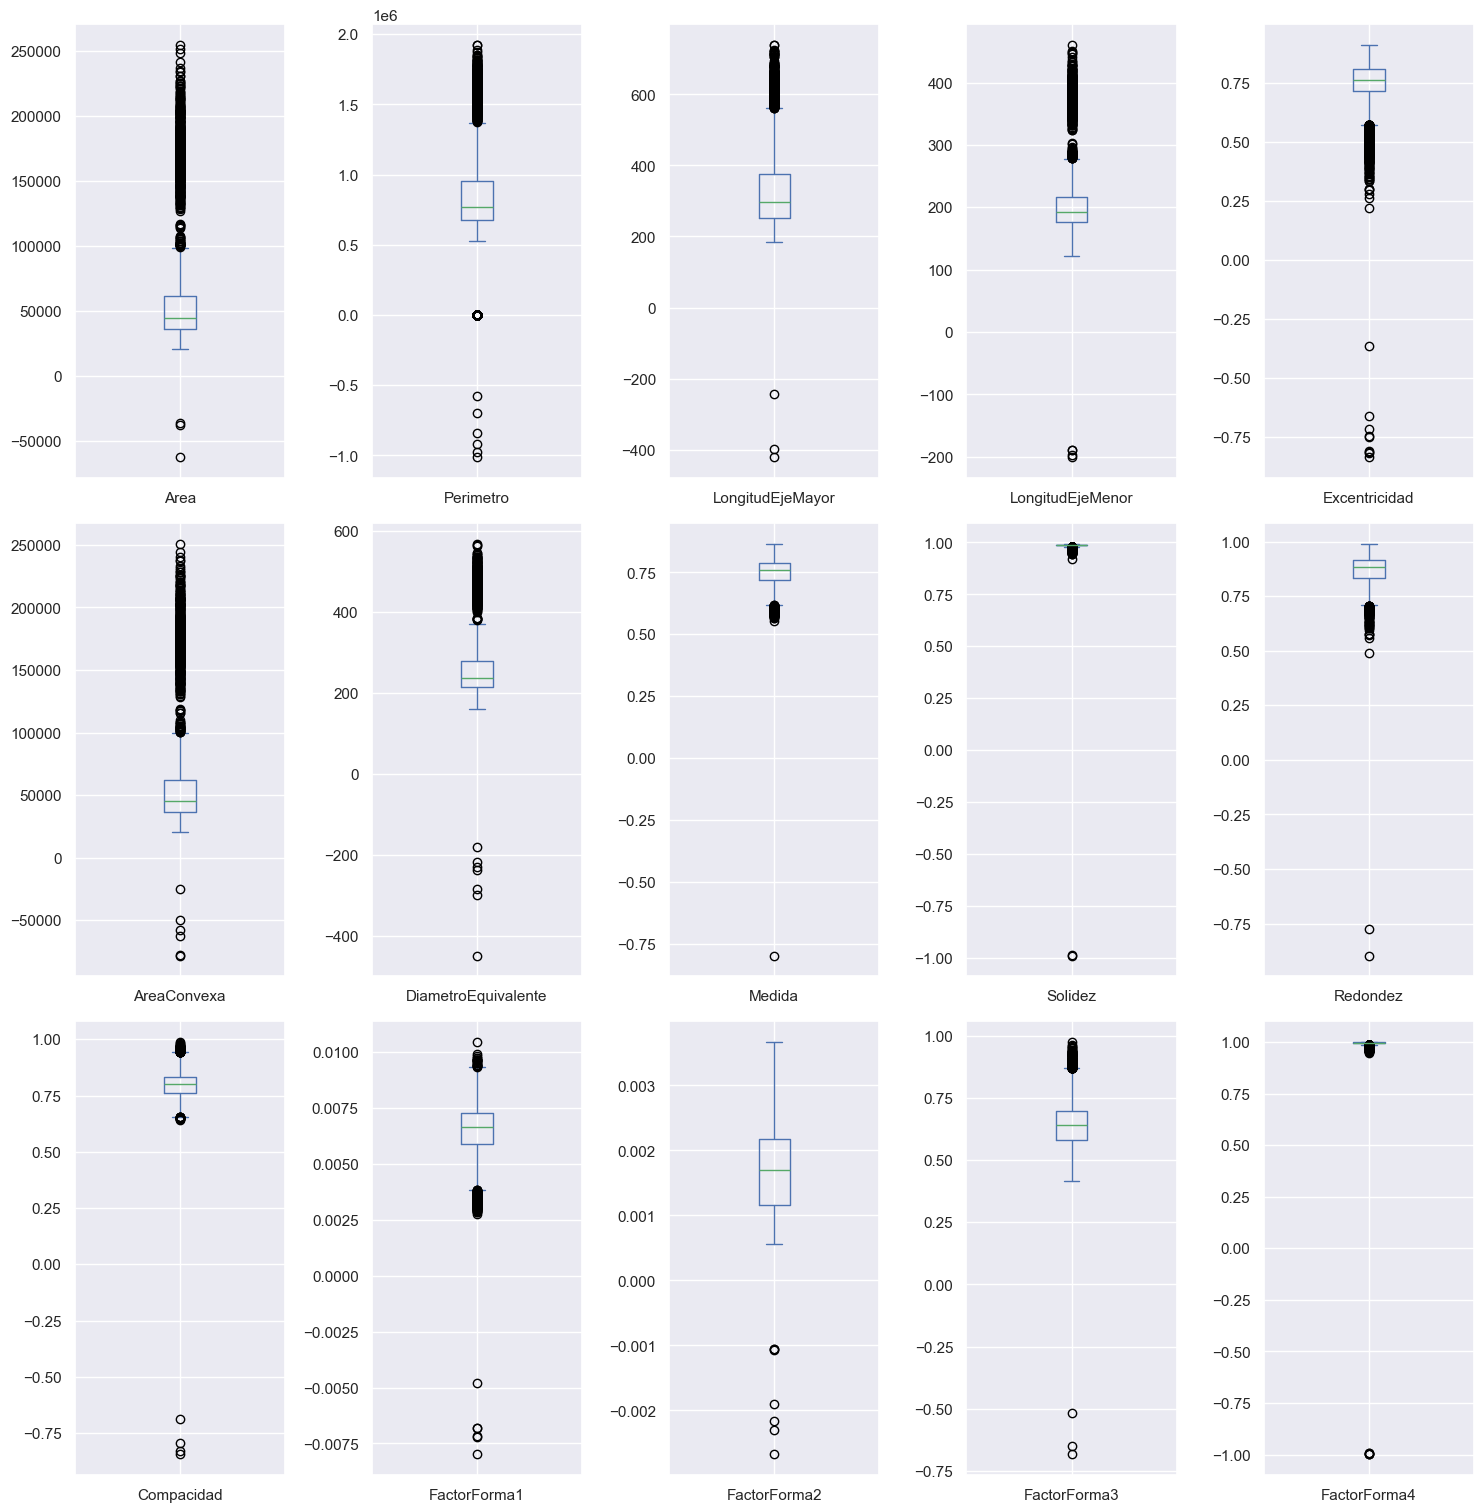

In [83]:
import matplotlib.pyplot as plt

df.plot(
    kind="box",
    subplots=True,
    layout=(int(len(df.columns) / 5) + 1, 5),  # filas, cols
    figsize=(15, 5 * (len(df.columns) // 5 + 1)),
    sharex=False,
    sharey=False,
)

plt.tight_layout()
plt.show()

In [40]:
# Revisar el contenido de las variables que no son numéricas, en este caso son categóricas
df[cat_cols].describe()

,ID,RelacionAspecto,DefectoVisible,MétodoSecado
count,14291,13825,11356,13704
unique,13611,4,2,6
top,G012961,Alargado,Normal,Lavado
freq,2,12047,9096,6260


In [41]:
# Revisar el contenido de las variables que son numéricas, en este caso son categóricas
df[num_cols].describe()

,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,Excentricidad,AreaConvexa,DiametroEquivalente,Medida,Solidez,Redondez,Compacidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4
count,14291.000000,1.305400e+04,13890.000000,14291.000000,13687.000000,12868.000000,12368.000000,14291.000000,11985.000000,12228.000000,13641.000000,13172.000000,13185.000000,13813.000000,13132.000000
mean,53055.408999,7.729870e+05,319.985592,202.178613,0.749977,53575.397809,253.001741,0.749844,0.986774,0.873080,0.799242,0.006560,0.001712,0.643183,0.994292
std,29396.080372,3.266493e+05,86.378452,45.494541,0.099438,29566.387814,60.542330,0.050774,0.025947,0.063237,0.067643,0.001164,0.000601,0.100857,0.039081
min,-62716.000000,-1.012143e+06,-421.444657,-200.838672,-0.835004,-78423.000000,-448.402605,-0.798706,-0.989042,-0.896861,-0.843901,-0.007982,-0.002673,-0.683269,-0.998527
25%,36338.000000,6.768608e+05,253.319858,175.881052,0.715144,36720.000000,215.302463,0.718767,0.985597,0.832824,0.762127,0.005903,0.001151,0.581047,0.993663
50%,44660.000000,7.720345e+05,296.682345,192.437870,0.764392,45107.500000,238.579492,0.760232,0.988279,0.883353,0.800994,0.006645,0.001691,0.641648,0.996377
75%,61311.000000,9.554098e+05,376.548109,216.847844,0.810441,62109.250000,279.672481,0.786942,0.989991,0.916803,0.834405,0.007273,0.002169,0.696366,0.997889
max,254616.000000,1.921685e+06,738.860154,460.198497,0.911423,251082.000000,569.374358,0.866195,0.994378,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


<Figure size 3000x800 with 0 Axes>

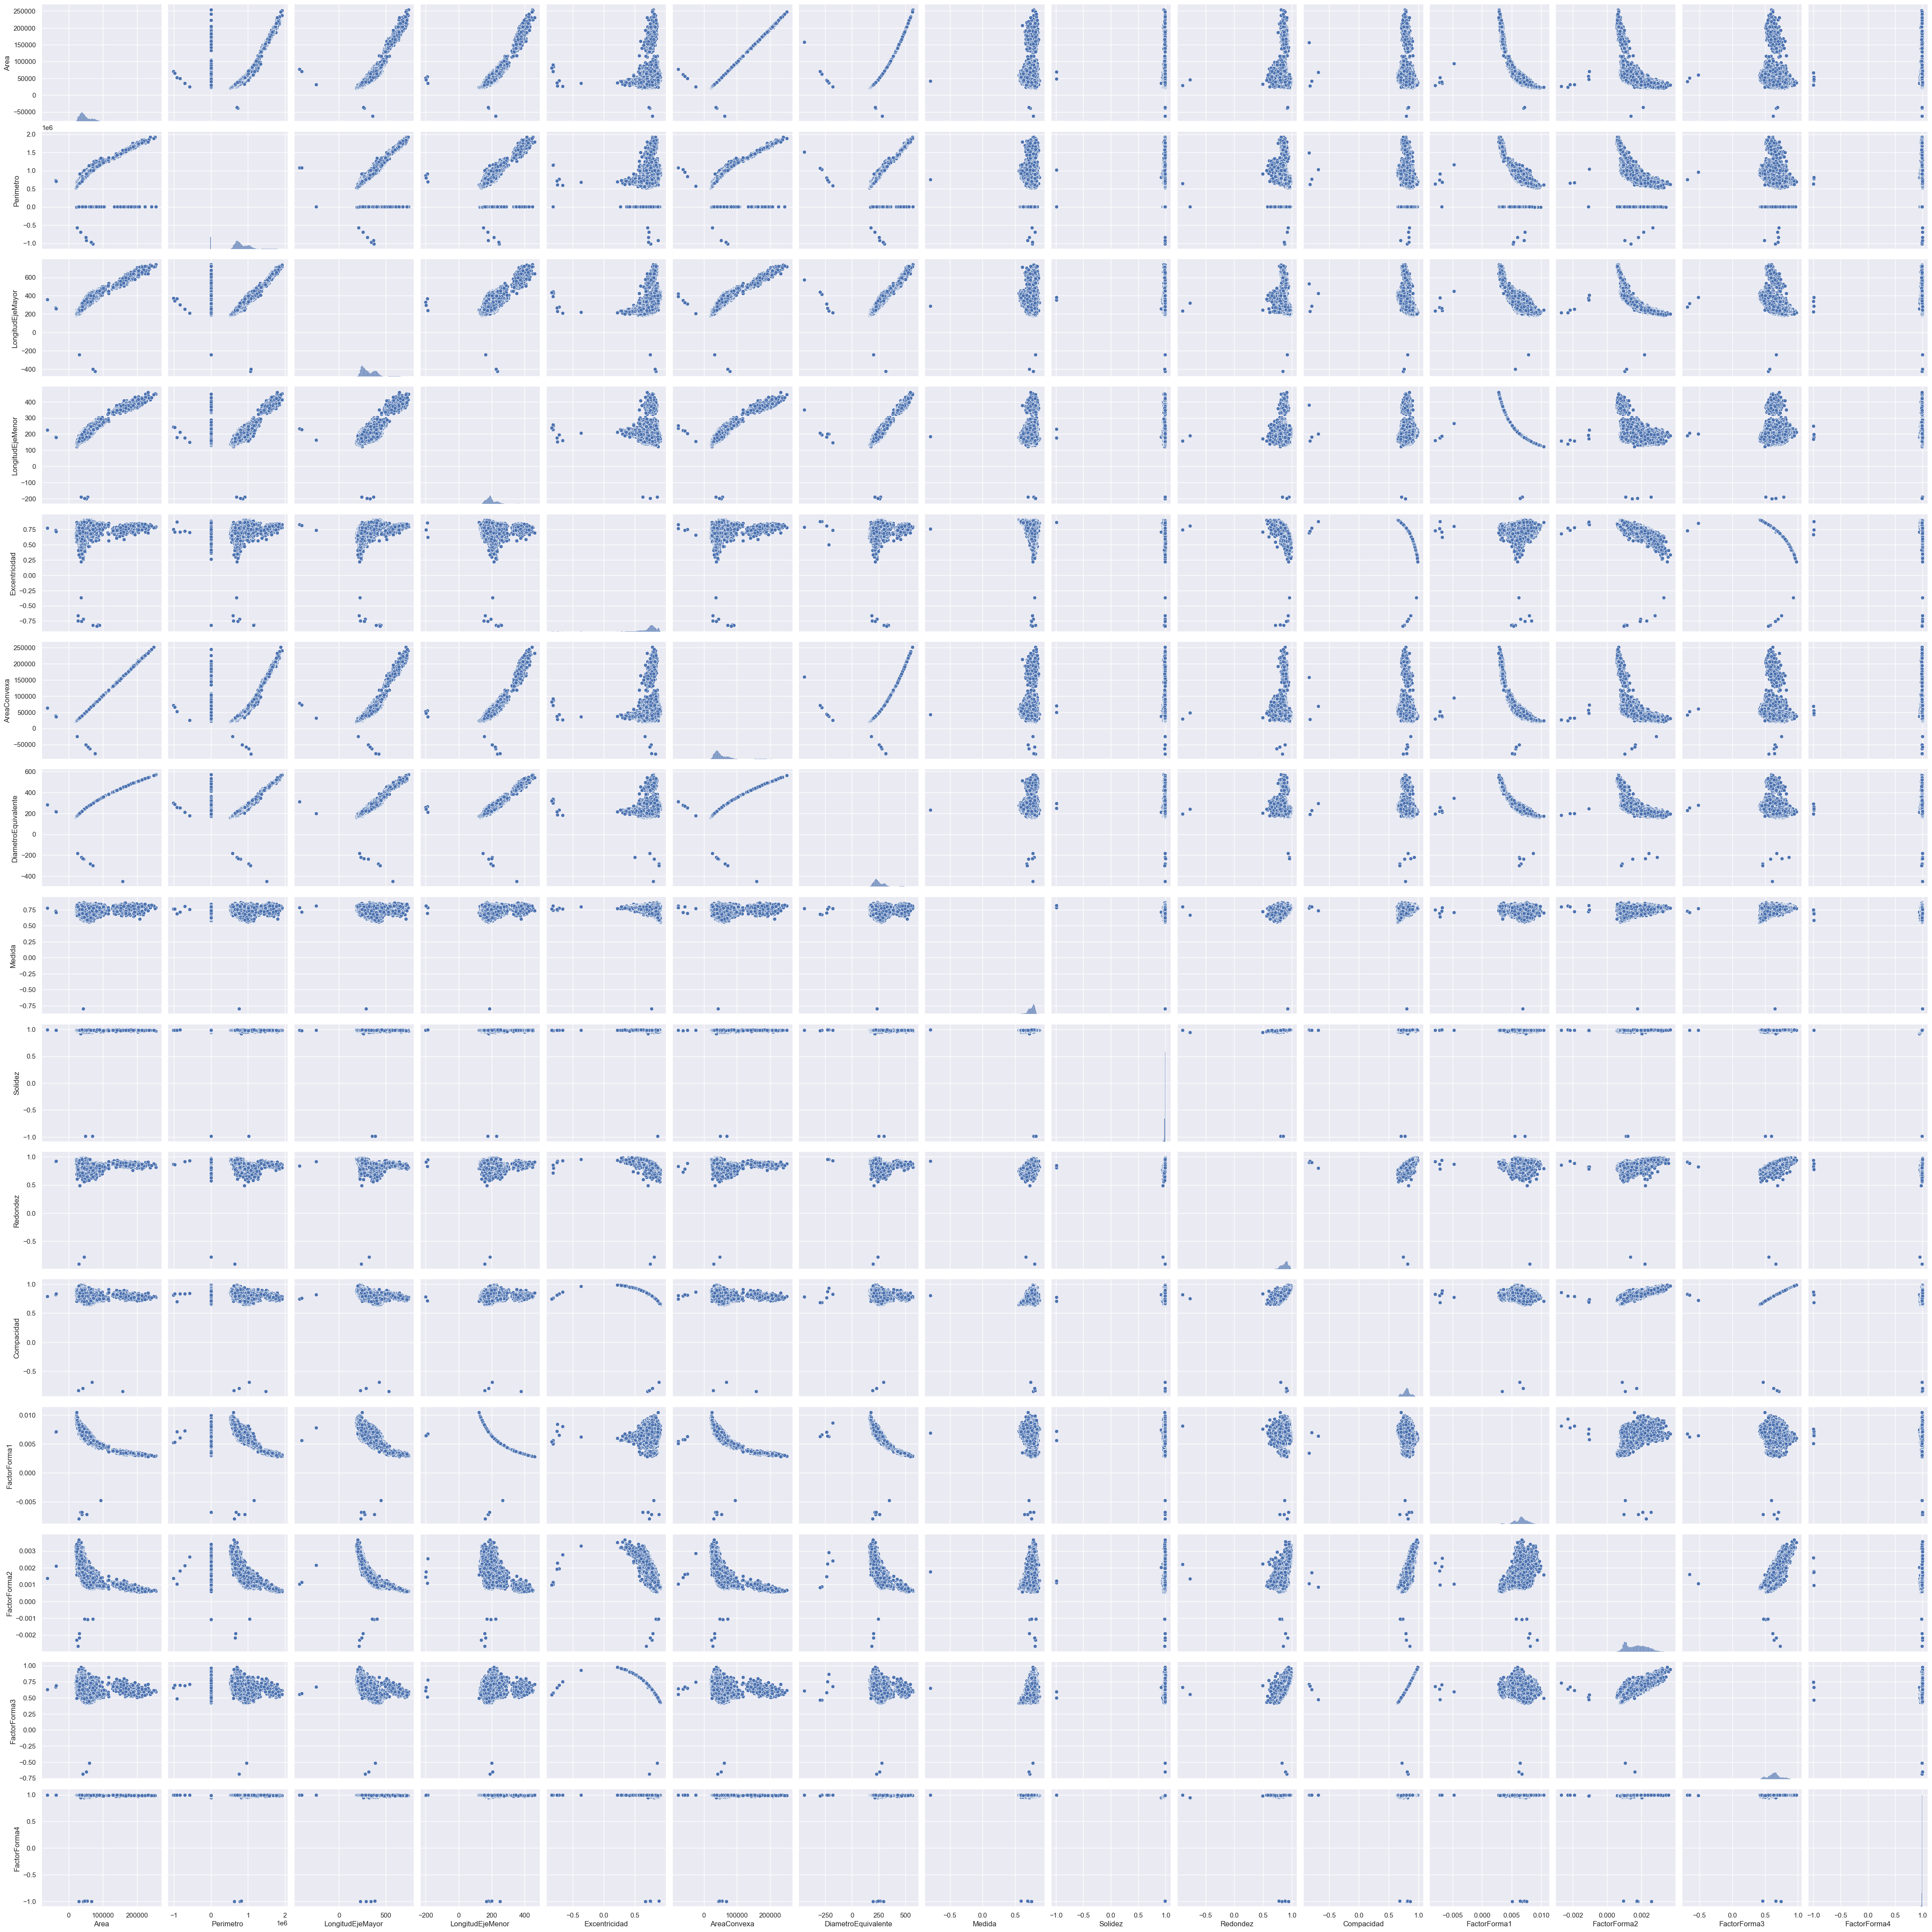

In [81]:
# Vámos las relaciones entre todas las variables numércias
plt.figure(figsize=(30, 8))
sns.pairplot(df[num_cols], height=3)

**Análisis** 
1. Observamos que se identifican varios grupos en gran parte de las variables, aproximadamente se observan entre 2 a 3 grupos entre las variables, con 1 o 2 grupos que tienen la mayos parte de los datos
  
2. Las variables categoricas tienes errores de consistencia, donde las caregorias de estas variables tienen el nombre mal escrito y lo toma como otra categoria diferente.

3.

In [123]:
# Consulto una muestra de datos para analizarlos mejor
df_cafe = df.copy()
df_cafe.sample(15)

,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,RelacionAspecto,Excentricidad,AreaConvexa,DiametroEquivalente,Medida,Solidez,Redondez,Compacidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4,DefectoVisible,MétodoSecado
5557,57311,953118.00,373.242876,196.567963,Alargado,NaN,58213.0,270.130767,0.640160,0.984505,0.792783,0.723740,0.006513,0.001102,0.523799,0.994589,Normal,Natural
6633,45903,807111.00,309.799576,189.314123,Alargado,0.791564,46388.0,241.755072,0.750000,0.989545,0.885492,0.780360,0.006749,NaN,0.608961,0.996523,Normal,Lavado
5563,88390,1146525.00,442.488022,256.062568,Alargado,0.815549,89104.0,335.472269,0.819815,0.991987,0.844979,0.758150,0.005006,0.001020,0.574791,NaN,normal,Unknown
6742,103899,1240.06,488.420973,273.382226,Alargado,0.828677,105229.0,363.714607,0.825414,0.987361,0.849055,0.744674,0.004701,0.000892,0.554540,0.990734,Unknown,Unknown
11042,44278,776522.00,279.807349,201.891088,Alargado,0.692377,44719.0,237.437361,0.719967,NaN,0.922763,0.848574,0.006319,0.002021,0.720079,0.997980,Normal,Natural
5801,38130,732.24,279.292924,174.061258,Alargado,0.782046,38529.0,220.337523,0.803210,NaN,0.893655,0.788912,0.007325,0.001750,NaN,NaN,Unknown,Lavado
12874,44691,NaN,297.858034,191.526498,Alargado,0.765856,45217.0,238.542132,0.703042,0.988367,0.875874,0.800858,0.006665,0.001691,0.641374,0.997452,Normal,Natural
964,78838,1101545.00,439.598771,230.806897,Alargado,NaN,79863.0,316.827491,0.754922,0.987166,0.816471,0.720720,0.005576,0.000928,0.519437,0.989328,Normal,Lavado
176,53042,896923.00,359.649768,189.192719,Alargado,0.850455,53863.0,259.875301,0.811536,0.984758,0.828551,0.722579,0.006780,0.001140,0.522120,0.992535,Normal,Lavado
6385,67455,1001021.00,386.597548,223.784502,Alargado,0.815429,68436.0,NaN,0.763411,0.985665,NaN,0.758059,0.005731,0.001167,0.574654,0.992739,Unknown,lavado


### 3.2. Análisis de calidad de datos

Revisamos las dimensiones de calidad: unicidad, completitud, consistencia, validez.
En particular miramos si se presenta algún problema de calidad relacionado con la dimensión y pensamos en opciones para la corrección. 

### 3.2.1 Completitud - Análisis de valores nulos o vacíos

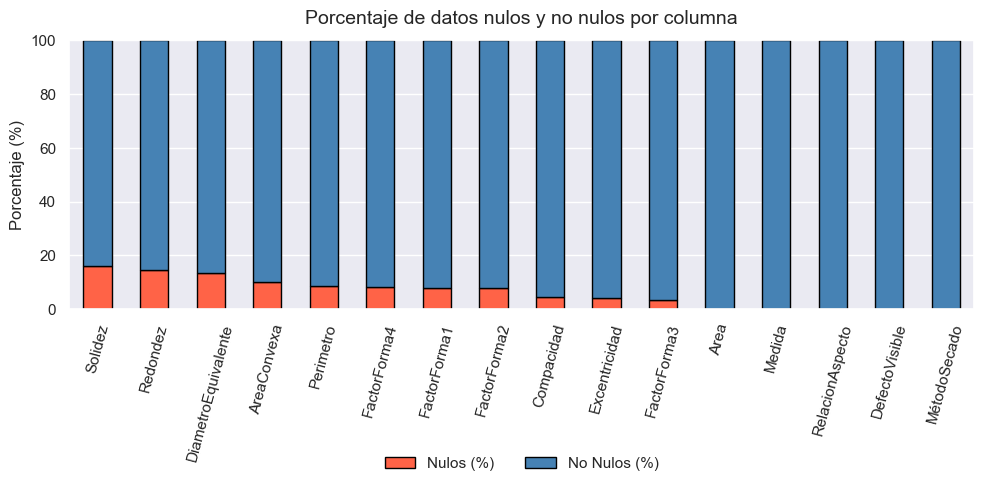

In [ ]:
# Cálculo de porcentaje de valores nulos por columna
((df_cafe.isnull().sum() / df_cafe.shape[0])).sort_values(ascending=False)

# Calculamos % de nulos y no nulos
na_percent = df_cafe.isnull().sum() / df_cafe.shape[0] * 100
valid_percent = 100 - na_percent

df_na = pd.DataFrame(
    {"Nulos (%)": na_percent, "No Nulos (%)": valid_percent}
).sort_values("Nulos (%)", ascending=False)

# Gráfico apilado
df_na.plot(kind="bar",stacked=True,color=["tomato", "steelblue"],
           figsize=(10, 6),
            edgecolor="black")

plt.title("Porcentaje de datos nulos y no nulos por columna", fontsize=14, pad=12)
plt.ylabel("Porcentaje (%)", fontsize=12)
plt.xlabel(" ",)
plt.xticks(rotation=75)
plt.ylim(0, 100)  # Siempre hasta 100%
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.5), ncol=2, frameon=False)
plt.tight_layout()
plt.show()




Antes de aplicar tecnicas de agrupacion, es importante manejar valores NA ya que los algoritmos propuestos no pueden manejar los datos incompletos drectamente. 

### 3.2.2 Unicidad

En este punto si se tienen las filas idénticas que representa duplicidad de los datos..

In [112]:
antes = df_cafe.shape[0]
df_cafe = df_cafe.drop_duplicates(keep="first")
despues = df_cafe.shape[0]
print("Filas eliminadas:", antes - despues)

Filas eliminadas: 0


In [113]:
# Verificamos que no hayan duplicados
df_cafe.duplicated().sum()

np.int64(0)

### 3.2.3 Consistencia

1. Observamos valores mal escritos en variables como `RelacionAspecto`, `DefectoVisible`, `MétodoSecado`

In [ ]:
# Revisamos los valores de la variable categórica 'RelacionAspecto'
df_cafe.RelacionAspecto.value_counts()

RelacionAspecto
Alargado      11662
Redondeado     1678
Unknown         448
alargado         29
redondeado       10
Name: count, dtype: int64

In [ ]:
df_cafe["RelacionAspecto"] = df_cafe["RelacionAspecto"].replace(
    {"alargado": "Alargado", "redondeado": "Redondeado"}
)
df_cafe.RelacionAspecto.value_counts()

In [ ]:
# Revisamos los valores de la variable categórica 'DefectoVisible'
df_cafe.DefectoVisible.value_counts()

DefectoVisible
Normal     8746
Unknown    2832
normal     2249
Name: count, dtype: int64

In [120]:
df_cafe["DefectoVisible"] = df_cafe["DefectoVisible"].replace({"normal": "Normal"})
df_cafe.DefectoVisible.value_counts()

DefectoVisible
Normal     10995
Unknown     2832
Name: count, dtype: int64

In [121]:
# Revisamos los valores de la variable categórica 'MétodoSecado'
df_cafe.MétodoSecado.value_counts()

MétodoSecado
Lavado     5989
Natural    4493
lavado     1540
natural    1168
Unknown     562
Honey        62
honey        13
Name: count, dtype: int64

In [122]:
df_cafe["MétodoSecado"] = df_cafe["MétodoSecado"].replace(
    {"lavado": "Lavado", "natural": "Natural", "honey": "Honey"}
)
df_cafe.MétodoSecado.value_counts()

MétodoSecado
Lavado     7529
Natural    5661
Unknown     562
Honey        75
Name: count, dtype: int64

In [124]:
df_cafe.describe()

,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,Excentricidad,AreaConvexa,DiametroEquivalente,Medida,Solidez,Redondez,Compacidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4
count,13829.000000,1.263200e+04,13441.000000,13829.000000,13247.000000,12448.000000,11977.000000,13829.000000,11611.000000,11822.000000,13196.000000,12742.000000,12762.000000,13369.000000,12706.000000
mean,52987.819148,7.718161e+05,319.764381,202.087990,0.749912,53522.234817,252.859725,0.749697,0.986761,0.873062,0.799317,0.006561,0.001713,0.643276,0.994272
std,29290.519559,3.267863e+05,86.158485,45.381468,0.099586,29473.518163,60.411500,0.050768,0.026348,0.063418,0.067764,0.001164,0.000601,0.100762,0.039721
min,-62716.000000,-1.012143e+06,-421.444657,-200.838672,-0.835004,-78423.000000,-448.402605,-0.798706,-0.989042,-0.896861,-0.843901,-0.007982,-0.002673,-0.683269,-0.998527
25%,36340.000000,6.767762e+05,253.298892,175.842829,0.715475,36720.000000,215.295810,0.718669,0.985596,0.832793,0.762221,0.005903,0.001153,0.581216,0.993680
50%,44642.000000,7.718650e+05,296.471648,192.411751,0.764169,45090.000000,238.542132,0.759942,0.988281,0.883436,0.801161,0.006647,0.001693,0.641936,0.996380
75%,61261.000000,9.543515e+05,376.463359,216.805272,0.810402,62092.250000,279.455579,0.786893,0.989989,0.916818,0.834374,0.007274,0.002169,0.696231,0.997889
max,254616.000000,1.921685e+06,738.860154,460.198497,0.911423,251082.000000,569.374358,0.866195,0.994378,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


En variables relacionadas con la medida del grano se tiene una escala mucho mayor a lo que deberia ser (`Área`, `Perimetro`, `LongitudEjeMayor`, `LongitudEjeMenor`, `)

### 3.2.4 Validez

Revisamos los valores distintos de las diferentes variables, aún no revisadas, para validar su valor. En este caso es dificil ya que no hay valores de referencia dados por BiciAlpes.

In [25]:
df_bicis['Vehicle_Type'].unique()

array(['bike'], dtype=object)

In [26]:
df_bicis['Light_Conditions'].unique()

array([1, 4, 6, 7, 5], dtype=int64)

Observamos que todas las filas compartidas tienen como tipo de vehículo bicicleta, así que esta columna no va a aportar en los análisis. A nivel de "Light_Conditions" no se observa nada raro.

## 4. Iteración 1. Primer modelo -- Fines pedagógicos
El objetivo de este primer modelo es comprender el funcionamiento general del algoritmo en términos de datos de entrada y resultado, con el fin de entender el aporte de esta tarea de agrupación al objetivo que se planteó el negocio. De la misma manera, se ilustra la forma como se evalúa el resultado obtenido, 

### 4.1 Preparar los datos
A nivel de preparación de datos debemos fijarnos en:
- A. Correcciones relacionadas con problemas de calidad de dato: nulos, duplicados, inconsistencia, diferencia de formatos, etc.
- B. Preparación relacionada con la tarea de aprendizaje
    - Selección de columnas a incluir de acuerdo con la tarea de aprendizaje a realizar y el conocimiento del contexto del negocio
    - ...
- C. Preparación de acuerdo con el algoritmo a utilizar, en este caso K-means
    Al revisar k-means vemos que el algoritmo trabaja únicamente con datos numéricos, y no nulos así que si vamos a incluir datos categóricos debemos transformarlos a numéricos y si tenemos datos nulos debemos transformalos y en el peor escenario retirarlos del modelo ya sea la fila que los incluye o toda la columna si el porcentaje de estos valores es alto.

<Span style="color:red">¿Será que el este algoritmo se ve afectado si las variables numéricas tienen magnitudes diferentes?</Span>

### 4.1.1 Identificar las variables a utilizar - les sugerimos dos de las numéricas 

In [27]:
#Preparación relacionada con el tipo B. Tipo de tarea de aprendizaje
#Vamos a seleccionar únicamente un subconjunto de variables numéricas para facilitar la creación del modelo
cols_select=["Number_of_Casualties","Speed_limit", "Number_of_Vehicles"]
df_bicis_model=df_bicis[cols_select].copy()


In [28]:
#El número de duplicados con respecto al conjunto de datos es diferente, ya que se tiene un subconjunto de variables-
df_bicis_model.duplicated(keep = False).sum()

5333

In [29]:
#Correcciones relacionadas con el tipo A. Calidad de datos
# Reemplazar los valores nulos por un valor diferente al contenido actual de las columnas
#En este punto hay que justificar la decisión. Por ejemplo, se trata de un 3% de filas y el experto estuvo de acuerdo con esta solución.
df_bicis_model=df_bicis[cols_select].copy()
#Eliminar duplicados
df_bicis_model.drop_duplicates(keep = 'first', inplace = True)
#Completar datos con valores nulos fillna(-99)

In [30]:
df_bicis_model.duplicated(keep = False).sum()

0

In [31]:
# Fijénse que el número de registros que nos queda es muy pequeño y podrá facilitar la interpretación
# continuaremos solo para explicar el funcionamiento del algoritmo y la forma de analizar el resultado.
df_bicis_model.shape

(19, 3)

In [32]:
#Si es crírito el caso
#sns.pairplot(df_bicis_model.dropna(), height=3,vars=['Light_Conditions','Number_of_Casualties'],kind='scatter')

In [33]:
df_bicis_model

,Number_of_Casualties,Speed_limit,Number_of_Vehicles
0,1,30.0,1
3,2,30.0,1
45,1,50.0,1
49,2,30.0,2
56,1,60.0,1
62,1,40.0,1
88,1,70.0,1
101,1,20.0,1
156,2,40.0,1
175,2,20.0,1


### 4.3 Construir el modelo
¿Qué función de scikilearn utilizar para realizar k-means y qué parámetros requiere?

In [34]:
# El negocio quiere que empecemos con calma, así que nos sugiere crear dos agrupaciones - k=2
model_kmeans = KMeans(n_clusters=2, random_state=0) 


In [35]:
#Si te sale el error: AttributeError: 'NoneType' object has no attribute 'split'
# al ejecutar este comando, puedes actualizr el  "threadpoolctl" a  3.1.0 con el comando pip install threadpoolctl==3.1.0
# más información: https://github.com/scikit-learn/scikit-learn/issues/24238
#Para ver la versión actual utiliza: print(sklearn.show_versions())
res_kmeans = model_kmeans.fit(df_bicis_model)

C:\Users\Maria Del Pilar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [36]:
#Consultar la etiqueta de la agrupación asignado a cada fila 
res_kmeans.labels_

array([1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0])

Es dificil de entender el resultado general viendo solo la etiqueta generada por el algoritmo, que corresponde al número de grupo al que pertenece una fila, por lo que acudimos a la visualización en gráficas.

### 4.4. Visualizar el resultado

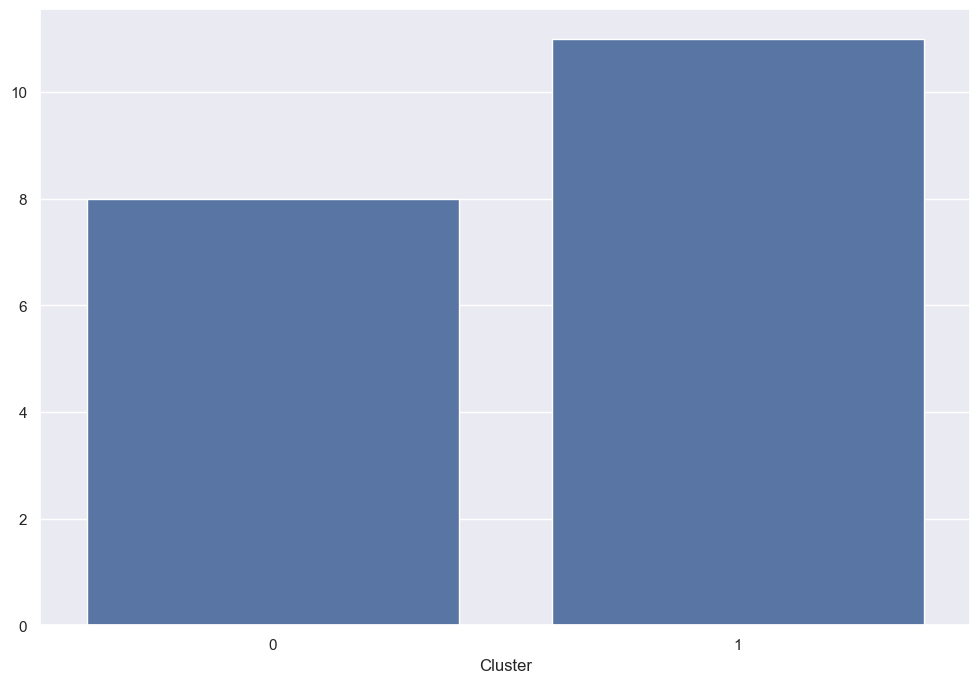

In [37]:
# Revisar la cantidad de registros en los grupos resultado
labels = res_kmeans.labels_
df_bicis_model['Cluster'] = labels

cluster_distrib = df_bicis_model['Cluster'].value_counts()

fig=plt.figure(figsize=(12,8))
sns.barplot(x=cluster_distrib.index, y=cluster_distrib.values, color='b');


In [38]:
# Revisar el número exacto de elementos por clúster y las variables utilizadas.
df_bicis_model.groupby('Cluster').count()

,Number_of_Casualties,Speed_limit,Number_of_Vehicles
Cluster,,,
0,8,8,8
1,11,11,11


In [39]:
#Transformar el contenido de las columnas a arreglo para facilitar aplicar funciones como las de visualización
cols_number = df_bicis_model.to_numpy()
cols_number

array([[ 1., 30.,  1.,  1.],
       [ 2., 30.,  1.,  1.],
       [ 1., 50.,  1.,  0.],
       [ 2., 30.,  2.,  1.],
       [ 1., 60.,  1.,  0.],
       [ 1., 40.,  1.,  1.],
       [ 1., 70.,  1.,  0.],
       [ 1., 20.,  1.,  1.],
       [ 2., 40.,  1.,  1.],
       [ 2., 20.,  1.,  1.],
       [ 2., 60.,  1.,  0.],
       [ 4., 30.,  1.,  1.],
       [ 2., 15.,  1.,  1.],
       [ 3., 30.,  1.,  1.],
       [ 2., 50.,  1.,  0.],
       [ 3., 50.,  1.,  0.],
       [ 3., 20.,  1.,  1.],
       [ 2., 60.,  2.,  0.],
       [ 2., 70.,  1.,  0.]])

In [40]:
df_bicis_model

,Number_of_Casualties,Speed_limit,Number_of_Vehicles,Cluster
0,1,30.0,1,1
3,2,30.0,1,1
45,1,50.0,1,0
49,2,30.0,2,1
56,1,60.0,1,0
62,1,40.0,1,1
88,1,70.0,1,0
101,1,20.0,1,1
156,2,40.0,1,1
175,2,20.0,1,1


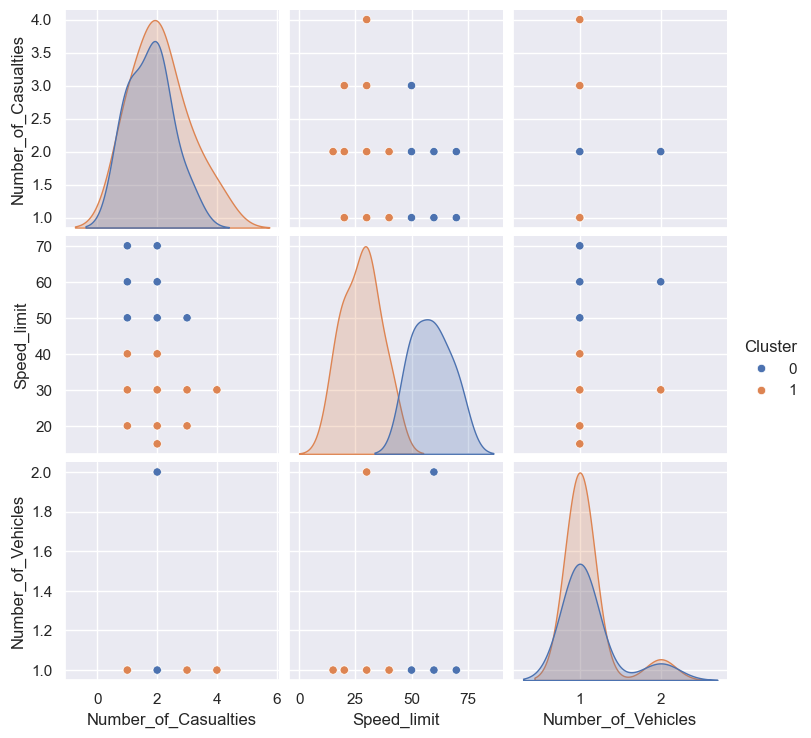

In [41]:
sns.pairplot(data=df_bicis_model, hue="Cluster")

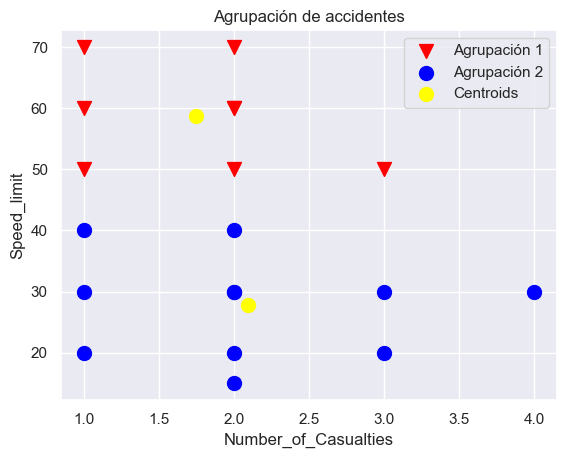

In [42]:
# Ver gráficamente en dos dimensiones -de acuerdo con el análisis de la gráfica anterior- las diferentes agrupaciones para poderlas describir mejor
# Recuerden que el describir los grupos es quizás una de las actividades más difíciles a nivel de la tarea de agrupación.
plt.scatter(cols_number[labels == 0, 0], cols_number[labels == 0, 1], s = 100, marker='v', c = 'red', label = 'Agrupación 1')
plt.scatter(cols_number[labels == 1, 0], cols_number[labels == 1, 1], s = 100, marker='o', c = 'blue', label = 'Agrupación 2')

plt.scatter(res_kmeans.cluster_centers_[:, 0], res_kmeans.cluster_centers_[:, 1], s = 100, c = 'yellow', label = 'Centroids')
plt.title('Agrupación de accidentes')
plt.xlabel(cols_select[0])
plt.ylabel(cols_select[1])
plt.legend()
plt.show()


In [43]:
# Revisemos los valores de los centroides de los clústeres generados. Esta información puede ser útil durante la evaluación cualitativa del modelo
print('Centroides: [[',cols_select[0], ' ' , cols_select[1], ']]', res_kmeans.cluster_centers_)

Centroides: [[ Number_of_Casualties   Speed_limit ]] [[ 1.75       58.75        1.125     ]
 [ 2.09090909 27.72727273  1.09090909]]


### 4.5 Evaluar la calidad del modelo construido

Se identifican dos tipos de evaluación: cuantitativa y cualitativa.
Desde el punto de vista cuantitativo vamos a utilizar la "silueta" que es lo que observamos en la celda siguiente.

In [44]:
#Creamos una función basada en el concepto de silueta
def plot_silhouette(data, 
                    labels,
                   ylabel = 'Grupos',
                   xlabel = "Coeficiente de silueta",
                   title = 'Gráfica de silueta'):
    '''
    Graficar la silueta de los clusters
    
    Parametros
    ----------
    data : np.array
        El arreglo con los datos
    labels : np.array
        El arreglo con las etiquetas correspondientes
    ylabel  string
        La etiqueta del eje y
    xlabel : string
        La etiqueta del eje x
    title : string
        El titulo de la gráfica        
    '''
    cluster_labels = np.unique(labels)
    print(cluster_labels)
    n_clusters = cluster_labels.shape[0]
    silhouette_vals = silhouette_samples(data,
                                        labels,
                                        metric='euclidean')
    y_ax_lower, y_ax_upper = 0, 0
    yticks = []
    for i, c in enumerate(cluster_labels):
        c_silhouette_vals = silhouette_vals[labels == c]
        c_silhouette_vals.sort()
        y_ax_upper += len(c_silhouette_vals)
        color = cm.jet(float(i) / n_clusters)
        plt.barh(range(y_ax_lower, y_ax_upper),
                        c_silhouette_vals,
                        height=1.0,
                        edgecolor='none',
                        color=color)
        yticks.append((y_ax_lower + y_ax_upper) / 2.)
        y_ax_lower += len(c_silhouette_vals)
    silhouette_avg = np.mean(silhouette_vals)
    plt.axvline(silhouette_avg,
                color="red",
                linestyle="--")
    plt.yticks(yticks, cluster_labels+1)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.title(title)
    plt.show()

[0 1]


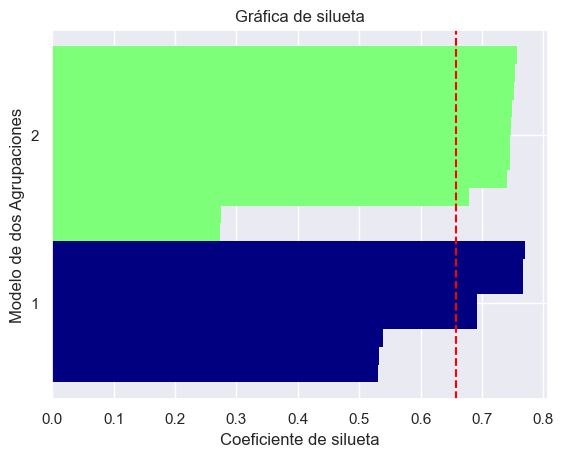

In [45]:
# Esta función puede tardar varios minutos
# Un valor cercano a 1 es un indicador de un bueno modelo. Revisa la teoría para comprender mejor el concepto
plot_silhouette(data = df_bicis_model, 
                labels = res_kmeans.labels_, 
                ylabel = 'Modelo de dos Agrupaciones')

La silueta es una medida intrínseca ya que no se conoce el resultado de esta tarea).  Se define en términos de qué tan compactos y separados están los clúster o grupos identificados.

**Compactos:** Distancia promedio al interior de un clúster
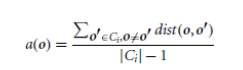

**Separados:** Mínima distancia promedio a otro clúster
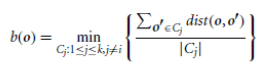

**Silueta:** Los valores cercanos a "1" son los mejores.
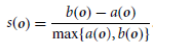

### 4.5 Analizar y concluir
Desde el punto de vista cuantitativo se identifica un buen valor de la silueta, cercano a 0.7, aunque hay que revisar los regisstros más lejanos a 1, para identificar lo que puede estar sucediendo y si es necesario regresar a la fase de preparación de los datos para ajustarlos y volver a construir el modelo. En este caso se observa que en el grupo 1(el morado en la gráfica) ha registros con una silueta por debajo de 0.3 y en el grupo 2 (verde en la gráfica), hay registros con siluetas por debajo a 0.6. Es posible que esos valores sean atípicos. 

A nivel cualitativo, se observa que la variable speed_limit es la varible que aporta más en las agrupaciones generadas, (ver el resultado de la celda con la instrucción -sns.pairplot(data=df_bicis_model, hue="Cluster")-. 
Esto puede llevar a que un funcionario, en este caso de secretaría de movilidad, proponga disminuir velocidades en ciertos tramos o fortalecer el cumplimiento del límite de  velocidad si ya se estableció y es apropiado.
Sin embargo, recordemos que no se ha hecho un tratamiento adecuado de variables ni de ajuste de hiperparámetros, por lo cual este modelo no es adecuado utilizarlo en el ambiente de BiciAlpes.

## 5. Iteración2. Segundo modelo con mejoras a nivel de preparación de datos y configuración de hiperparámetros
En esta iteración profundizaremos en la preparación de los datos para obtener resultados correctos y en la parte de configuración de hiperparámetros que lleven a mejores modelos. Es así como vamos a probar con un método para la selección del hiperparámetro k (número de agrupaciones a generar). 

### 5.1. Preparación de datos

In [46]:
#Selección de variables: Esta decisión puede sustentarse en la visualización de los datos y con los criterios dados por las personas de la organziación para la que se hace el proyecto.
#Te proponemos trabajar con las columnas numéricas de la iteración 1 pero en esta ocasión normalizadas, ¿entiendes por qué hacerlo? 
# Además, vamos a incluir una variable categórica con la preparación respectiva. ¿Por qué no utilizarla directamente si es numérica?
#En este punto es muy importante retomar el análisis a nivel de entendimiento de datos hecho y revisar de nuevo el diccionario de datos para entender la naturaleza de las variables compartidas

cols_select2=["Number_of_Casualties","Speed_limit","Number_of_Vehicles", "Time"]
cols_number=["Number_of_Casualties","Speed_limit","Number_of_Vehicles"]
cols_category=["Time"]
df_bicis_model2 = df_bicis[cols_select2].copy()

In [47]:
# Ejemplos de opciones para transformar una variable categórica a una numércia - LabelEncoder y OneHotEncoder
# En este ejemplo, usaremos OneHotEncoder
enc = OneHotEncoder(handle_unknown='ignore')
transformed = enc.fit_transform(df_bicis_model2[cols_category])
print(enc.categories_[0])
#Incluir en el dataframe la  transformación de la varibale Time 
df_bicis_model2[enc.categories_[0]] = transformed.toarray()


['Madrugada' 'Mañana' 'Noche' 'Tarde']


<Span style="color:red"> ¿Cómo me devuelvo y obtengo los valores originales para los análisis?</Span>

In [48]:
df_bicis_model2.describe()

,Number_of_Casualties,Speed_limit,Number_of_Vehicles,Madrugada,Mañana,Noche,Tarde
count,5338.000000,5338.000000,5338.000000,5338.000000,5338.000000,5338.000000,5338.000000
mean,1.118022,33.522855,1.001124,0.001124,0.315474,0.276695,0.406707
std,0.330694,10.206576,0.033511,0.033511,0.464748,0.447406,0.491265
min,1.000000,15.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,30.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,30.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,30.000000,1.000000,0.000000,1.000000,1.000000,1.000000
max,4.000000,70.000000,2.000000,1.000000,1.000000,1.000000,1.000000


In [49]:
#Guardar el nombre de las variables a utilizar en el modelo, incluyendo las nuevas columnas creadas relacionadas conla variable Time (Mañana, noche, tarde)
list_cols_transformed =np.array(enc.categories_[0]).tolist()
cols_transformed = cols_number+list_cols_transformed
cols_transformed

['Number_of_Casualties',
 'Speed_limit',
 'Number_of_Vehicles',
 'Madrugada',
 'Mañana',
 'Noche',
 'Tarde']

In [50]:
# Vamos a llevar al mismo dominio las diferentes variables
# ¿Entiendes por qué? En este punto puedes revisar otras opciones como la de estandarización o RobustScaler.
mms= MinMaxScaler()
# transform data
df_bicis_prep_norm = mms.fit_transform(df_bicis_model2[cols_transformed])
df_bicis_model2_norm = pd.DataFrame(df_bicis_prep_norm, columns =cols_transformed)
df_bicis_model2_norm['Time'] = df_bicis_model2['Time']

In [51]:
df_bicis_model2_norm

,Number_of_Casualties,Speed_limit,Number_of_Vehicles,Madrugada,Mañana,Noche,Tarde,Time
0,0.000000,0.272727,0.0,0.0,1.0,0.0,0.0,Mañana
1,0.000000,0.272727,0.0,0.0,1.0,0.0,0.0,Mañana
2,0.000000,0.272727,0.0,0.0,0.0,0.0,1.0,Tarde
3,0.333333,0.272727,0.0,0.0,0.0,0.0,1.0,Tarde
4,0.333333,0.272727,0.0,0.0,1.0,0.0,0.0,Mañana
...,...,...,...,...,...,...,...,...
5333,0.000000,0.090909,0.0,0.0,0.0,0.0,1.0,Tarde
5334,0.333333,0.272727,0.0,0.0,0.0,1.0,0.0,Noche
5335,0.000000,0.272727,0.0,0.0,0.0,0.0,1.0,Tarde
5336,0.000000,0.272727,0.0,0.0,0.0,1.0,0.0,Noche


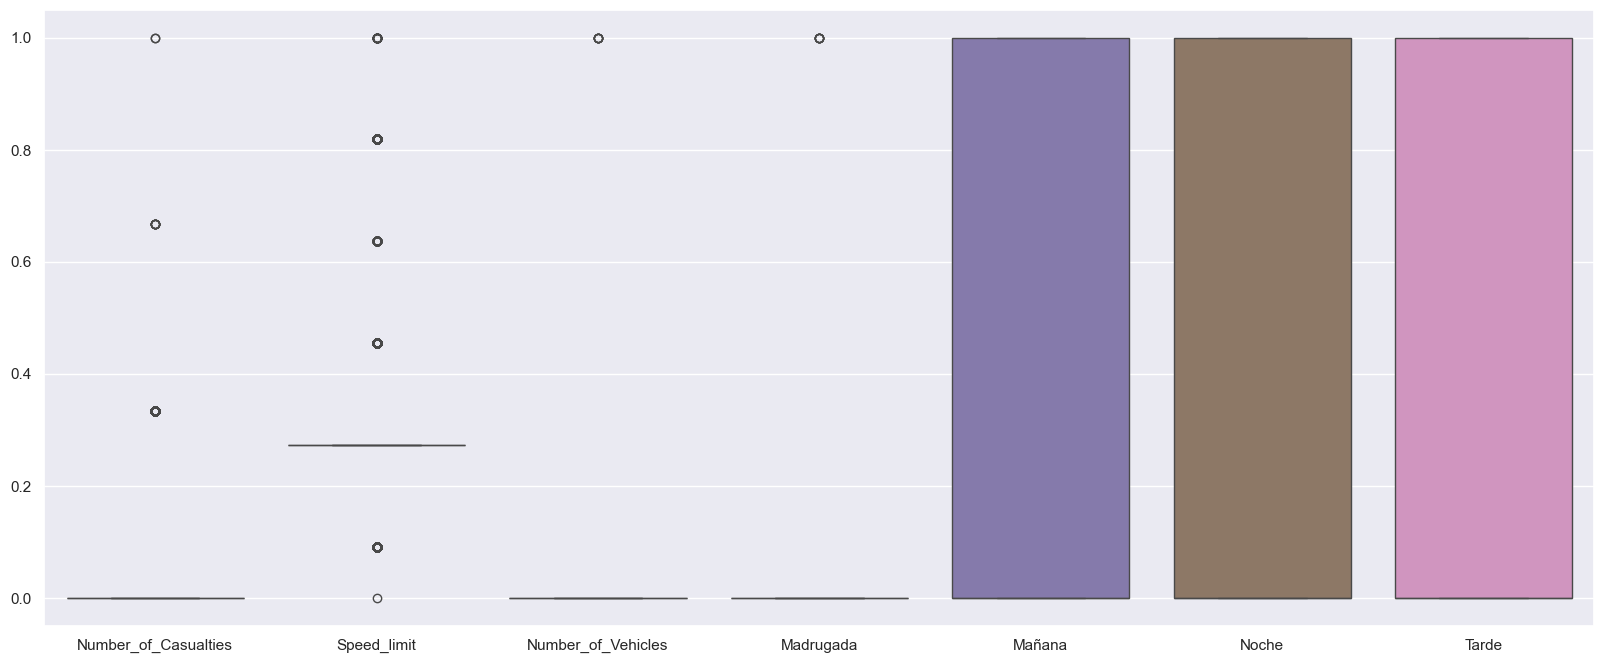

In [52]:
#Visualización de todas las variables numéricas de iipo int luego de la transformación
#¿Qué pasó con los valores atípicos?
fig=plt.figure(figsize=(20,8))
ax = sns.boxplot(data=df_bicis_model2_norm, orient="v")

### 5.2. Encontrar el número óptimo de clústeres utilizando el método del codo

El método del codo consiste en ejecutar con diferentes k el algoritmo y medir la métrica de dispersión. Esta métrica para el caso de la implementación de KMeans en scikitlearn, corresponde a la sumna de distanciass al cuadrado entre los puntos de un cluster y su centroide.

In [53]:
def plot_distortion(data,
                    k_min=1, 
                    k_max=11,
                    ylabel = 'Distortion',
                    xlabel = 'Number of clusters',
                    title = 'Distortion Plot'):
    '''
    Graficar el codo de los clusters
    
    Parametros
    ----------
    data : np.array
        El arreglo con los datos
    k_min : int
        Valor mínimo para k
    k_max : int
        Valor máximo para k
    xlabel : string
        La etiqueta del eje x
    ylabel  string
        La etiqueta del eje y    
    title : string
        El titulo de la gráfica  
    '''
    distortions = []
    for i in range(k_min, k_max):
        km = KMeans(n_clusters=i,
                 init='k-means++',
                 n_init=10,
                 max_iter=300,
                 random_state=0)
        km.fit(data)
        distortions.append(km.inertia_)
    plt.plot(range(k_min,k_max), distortions, marker='o')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

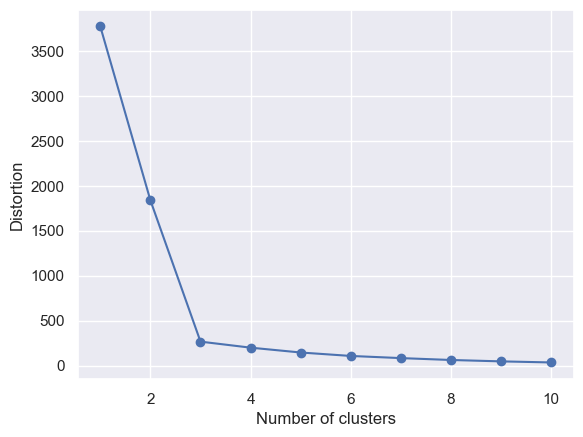

In [54]:
# En este gráfico vemos el punto en que cambia la pendiente y ese es el número sugerido para el valor de k o número de grupos.
# En este caso un valor de 3
plot_distortion(df_bicis_model2_norm[cols_transformed],1,11)

### 5.3. Construir el nuevo modelo con el número de clústeres obtenido

In [55]:
#En este punto generamos el modelo, con los datos preparados y la selección del número de grupos apoyada con el gráfico de silueta.
kmeans2 = KMeans(n_clusters=3, random_state=0) 
res_kmeans2 = kmeans2.fit(df_bicis_model2_norm[cols_transformed])


In [56]:
df_bicis_model2_norm

,Number_of_Casualties,Speed_limit,Number_of_Vehicles,Madrugada,Mañana,Noche,Tarde,Time
0,0.000000,0.272727,0.0,0.0,1.0,0.0,0.0,Mañana
1,0.000000,0.272727,0.0,0.0,1.0,0.0,0.0,Mañana
2,0.000000,0.272727,0.0,0.0,0.0,0.0,1.0,Tarde
3,0.333333,0.272727,0.0,0.0,0.0,0.0,1.0,Tarde
4,0.333333,0.272727,0.0,0.0,1.0,0.0,0.0,Mañana
...,...,...,...,...,...,...,...,...
5333,0.000000,0.090909,0.0,0.0,0.0,0.0,1.0,Tarde
5334,0.333333,0.272727,0.0,0.0,0.0,1.0,0.0,Noche
5335,0.000000,0.272727,0.0,0.0,0.0,0.0,1.0,Tarde
5336,0.000000,0.272727,0.0,0.0,0.0,1.0,0.0,Noche


### 5.4. Visualizar el resultado

### 5.4.1 Graficar la cantidad de registros por agrupación

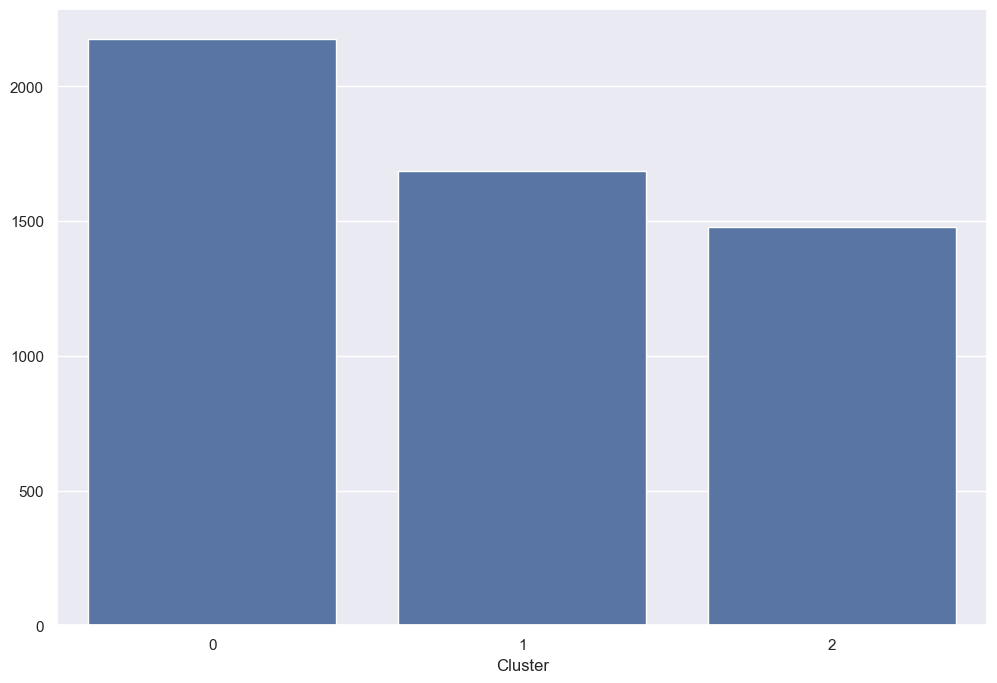

In [57]:
# Revisar la cantidad de registros en los clústeres resultado
labels = res_kmeans2.labels_
df_bicis_model2_norm['Cluster'] = labels
cluster_distrib = df_bicis_model2_norm['Cluster'].value_counts()
fig=plt.figure(figsize=(12,8))
sns.barplot(x=cluster_distrib.index, y=cluster_distrib.values, color='b');


In [58]:
# Revisar el número exacto de elementos por clúster y las variables utilizadas.
df_bicis_model2_norm.groupby('Cluster').count()

,Number_of_Casualties,Speed_limit,Number_of_Vehicles,Madrugada,Mañana,Noche,Tarde,Time
Cluster,,,,,,,,
0,2177,2177,2177,2177,2177,2177,2177,2177
1,1684,1684,1684,1684,1684,1684,1684,1684
2,1477,1477,1477,1477,1477,1477,1477,1477


In [59]:
# Consultamos algunos de los registros en el clúster 0.
#Transformar el contenido de las columnas a arreglo
cols_number2 = df_bicis_model2_norm.to_numpy()
cols_number2[res_kmeans2.labels_ == 0, len(cols_transformed)-1]

array([1.0, 1.0, 1.0, ..., 1.0, 1.0, 1.0], dtype=object)

### 5.4.2  Graficar comportamiento en parejas de atributos de acuerdo a la agrupación

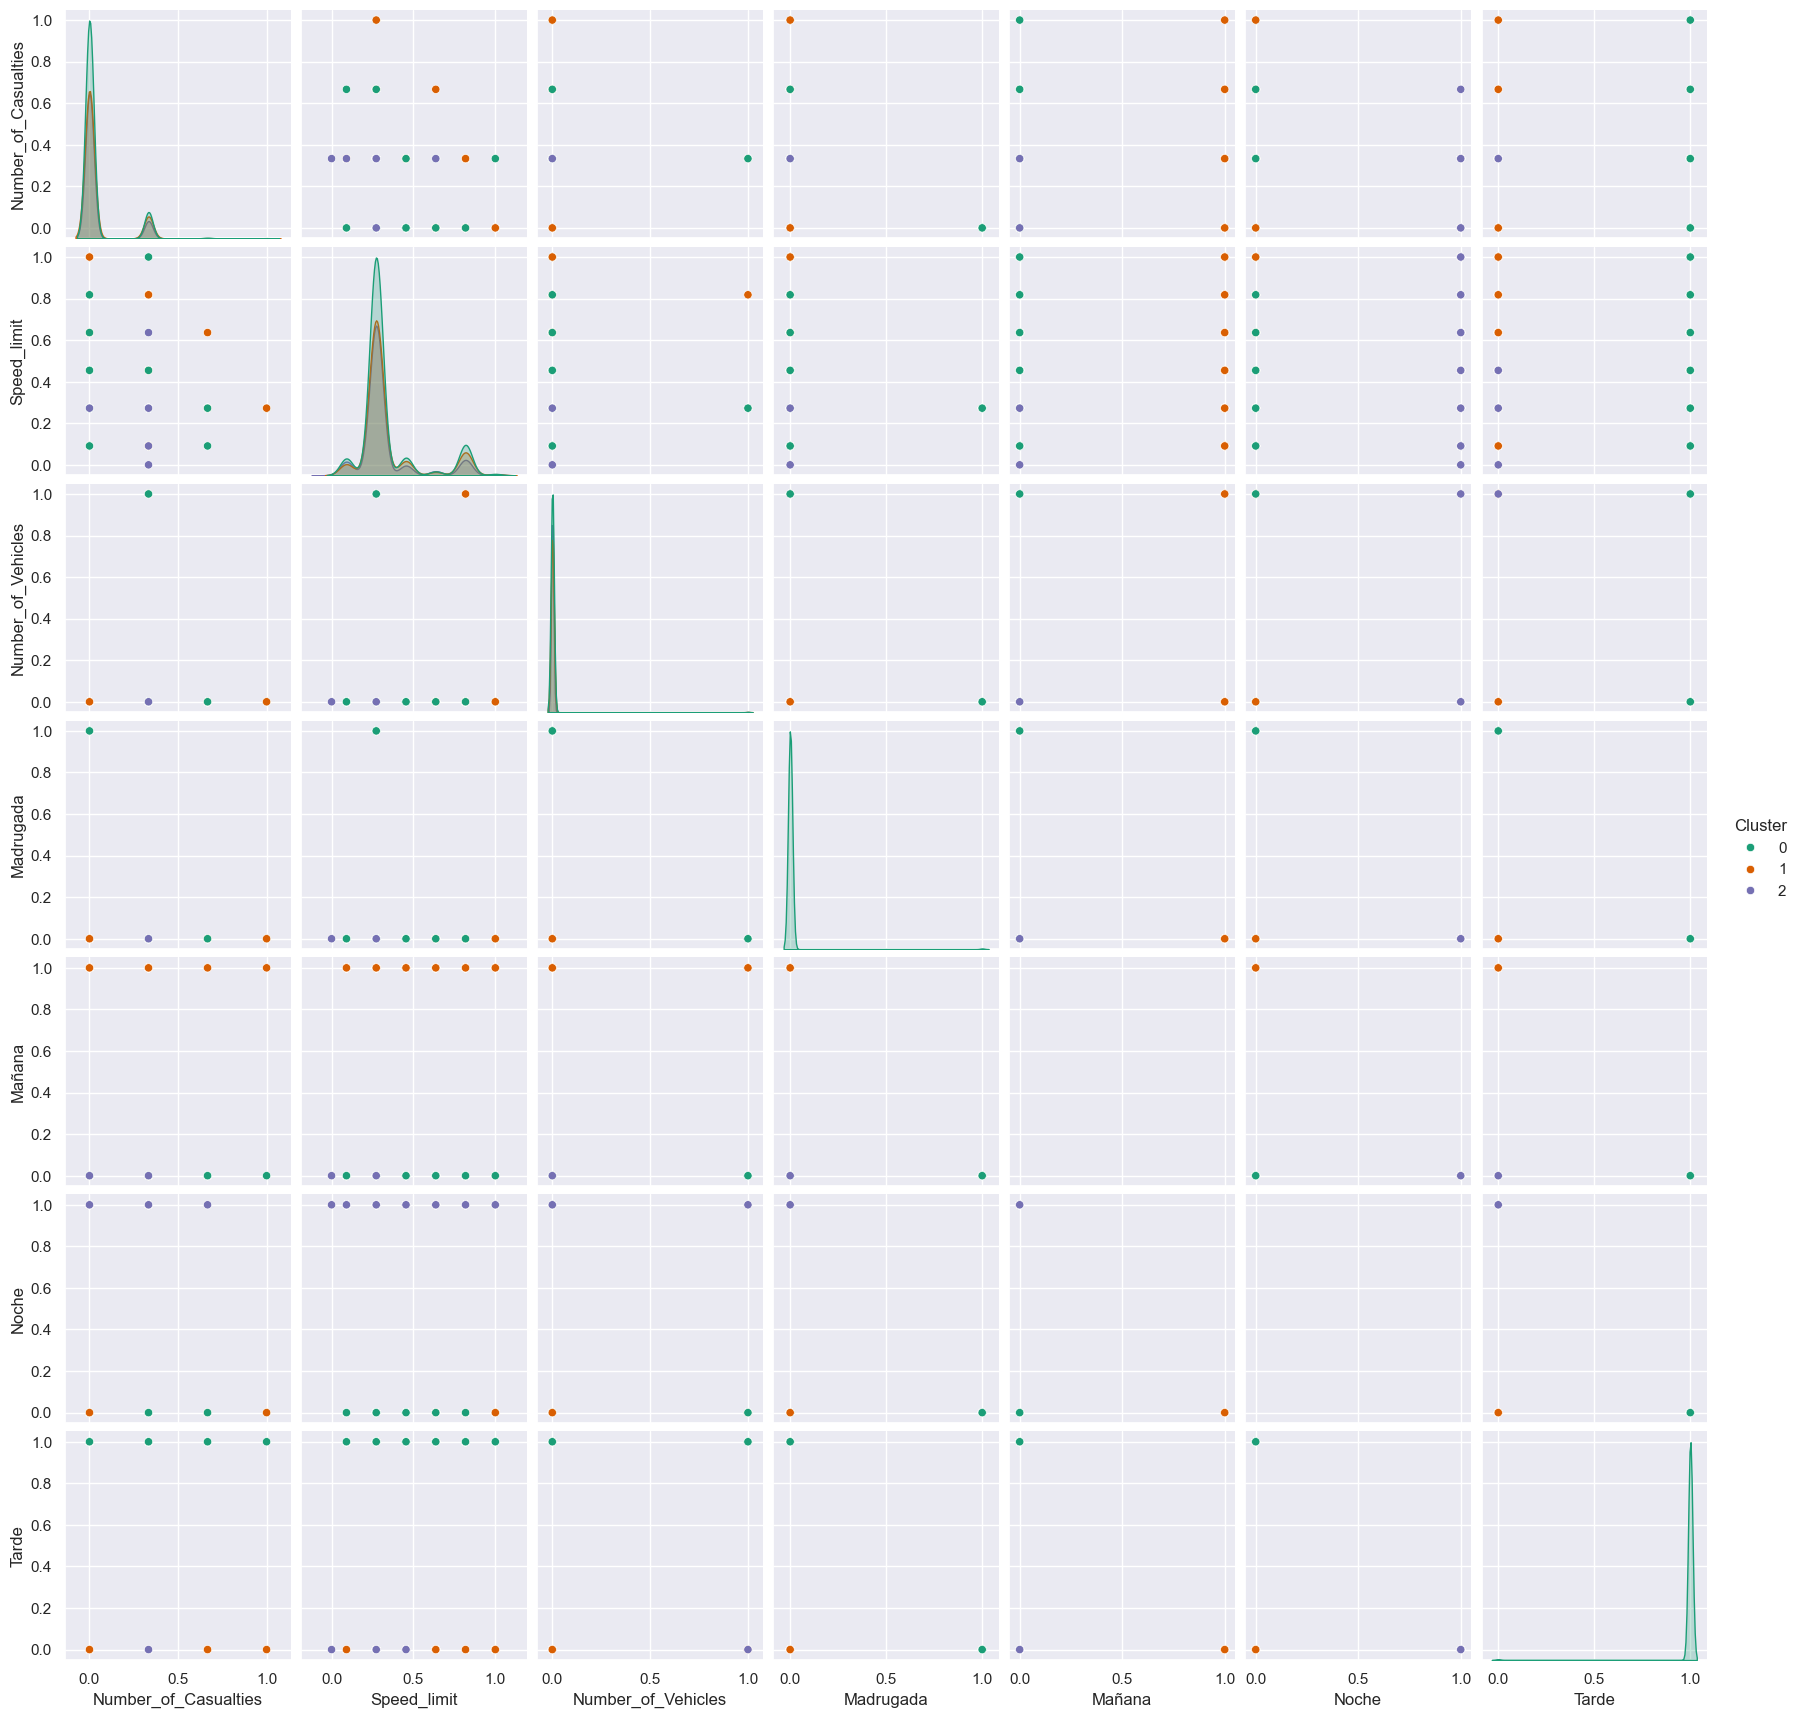

In [60]:
# El análisis de la gráfica es más dificil ya que son más columnas. Podrías filtrar las columnas para entender mejor el gráfico
# Ajustar la paleta de colores para ver mejor
sns.pairplot(data=df_bicis_model2_norm, hue="Cluster", palette="Dark2")

### 5.4.3  Graficar dos atributos y ver la relaciónn con las agrupaciones

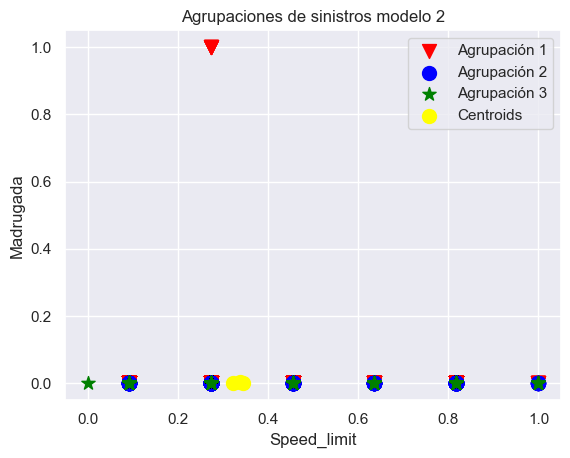

In [61]:
# El análisis lo haremos por pareja de atributos, en este caso 
plt.scatter(cols_number2[res_kmeans2.labels_ == 0, 1], cols_number2[kmeans2.labels_ == 0, 3], s = 100, marker='v', c = 'red', label = 'Agrupación 1')
plt.scatter(cols_number2[res_kmeans2.labels_ == 1, 1], cols_number2[kmeans2.labels_ == 1, 3], s = 100, marker='o', c = 'blue', label = 'Agrupación 2')
plt.scatter(cols_number2[res_kmeans2.labels_ == 2, 1], cols_number2[kmeans2.labels_ == 2, 3], s = 100, marker='*', c = 'green', label = 'Agrupación 3')

plt.scatter(res_kmeans2.cluster_centers_[:, 1], res_kmeans2.cluster_centers_[:, 3], s = 100, c = 'yellow', label = 'Centroids')
plt.title('Agrupaciones de sinistros modelo 2')
plt.xlabel(cols_transformed[1])
plt.ylabel(cols_transformed[3])
plt.legend()
plt.show()


In [62]:
# Revisemos los valores de los centroides de los clústeres generados
print('Centroides: [[',cols_transformed[0], ' ' , cols_transformed[1], ']]', res_kmeans2.cluster_centers_)

Centroides: [[ Number_of_Casualties   Speed_limit ]] [[3.78196295e-02 3.39040381e-01 1.37804318e-03 2.75608636e-03
  1.11022302e-16 2.77555756e-16 9.97243914e-01]
 [4.43388757e-02 3.45389765e-01 1.18764846e-03 0.00000000e+00
  1.00000000e+00 1.66533454e-16 1.05471187e-15]
 [3.58835477e-02 3.23628978e-01 6.77048070e-04 0.00000000e+00
  5.55111512e-17 1.00000000e+00 8.32667268e-16]]


### 5.4.4  Graficar los centroides de los grupos

In [63]:
cols_transformed

['Number_of_Casualties',
 'Speed_limit',
 'Number_of_Vehicles',
 'Madrugada',
 'Mañana',
 'Noche',
 'Tarde']

In [64]:
kmeans2.cluster_centers_.tolist()

[[0.03781962945950082,
  0.3390403808410239,
  0.0013780431786862611,
  0.0027560863573725296,
  1.1102230246251565e-16,
  2.7755575615628914e-16,
  0.9972439136426294],
 [0.044338875692794925,
  0.3453897646296696,
  0.0011876484560570052,
  0.0,
  1.000000000000001,
  1.6653345369377348e-16,
  1.0547118733938987e-15],
 [0.03588354773188895,
  0.3236289776574136,
  0.0006770480704129985,
  0.0,
  5.551115123125783e-17,
  0.9999999999999998,
  8.326672684688674e-16]]

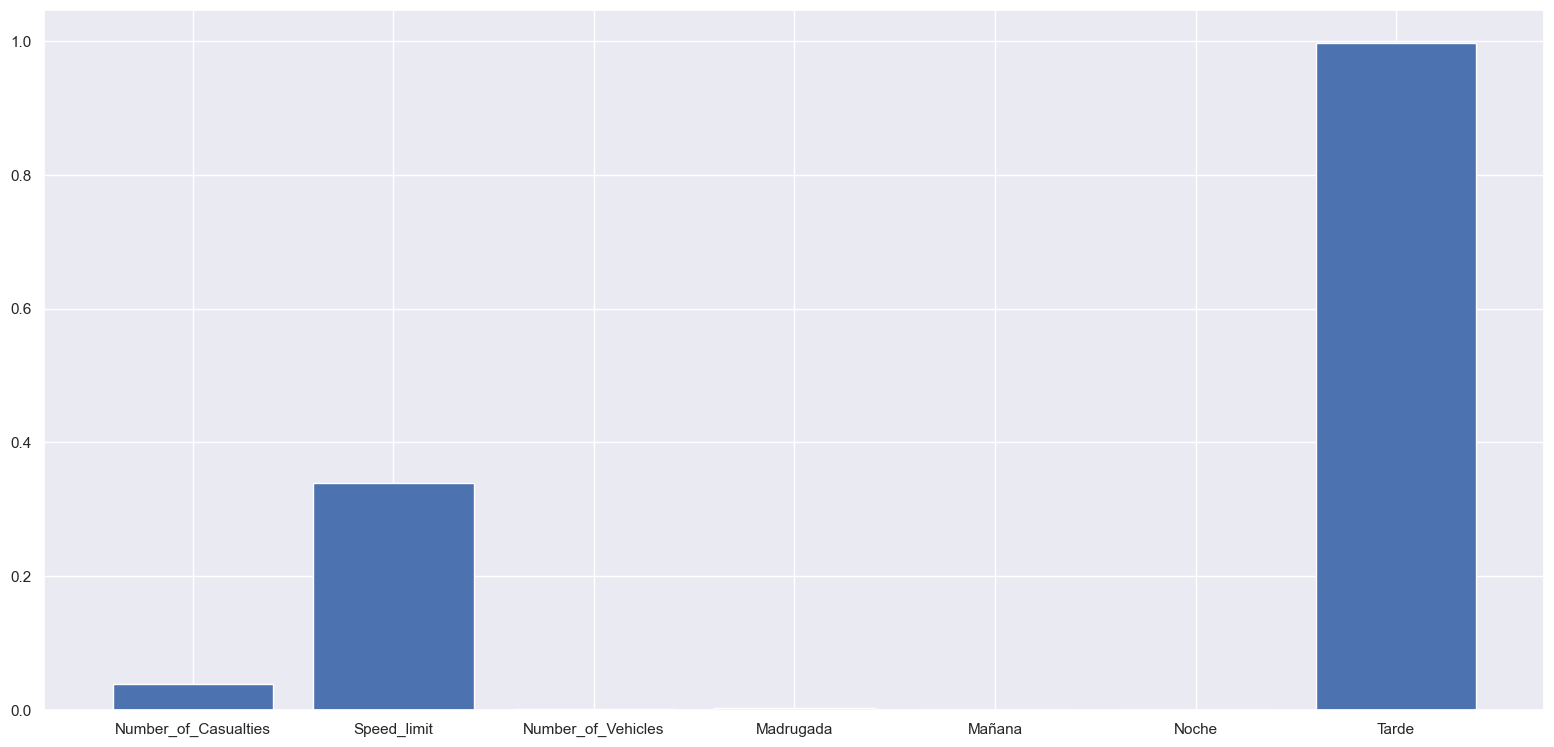

In [65]:
#visualizar los centroides de un cluster. En el ejemplo, el grupo 0. 
# En este caso dado que los datos están normalizados los valores de algunas variables son muy pequeños y no se observan en la gráfica, por ejemplo: Num_vehicles
fig = plt.figure(figsize=(15, 7))
ax = fig.add_axes([0,0,1,1])
ax.bar(cols_transformed,res_kmeans2.cluster_centers_.tolist()[0])
plt.show()

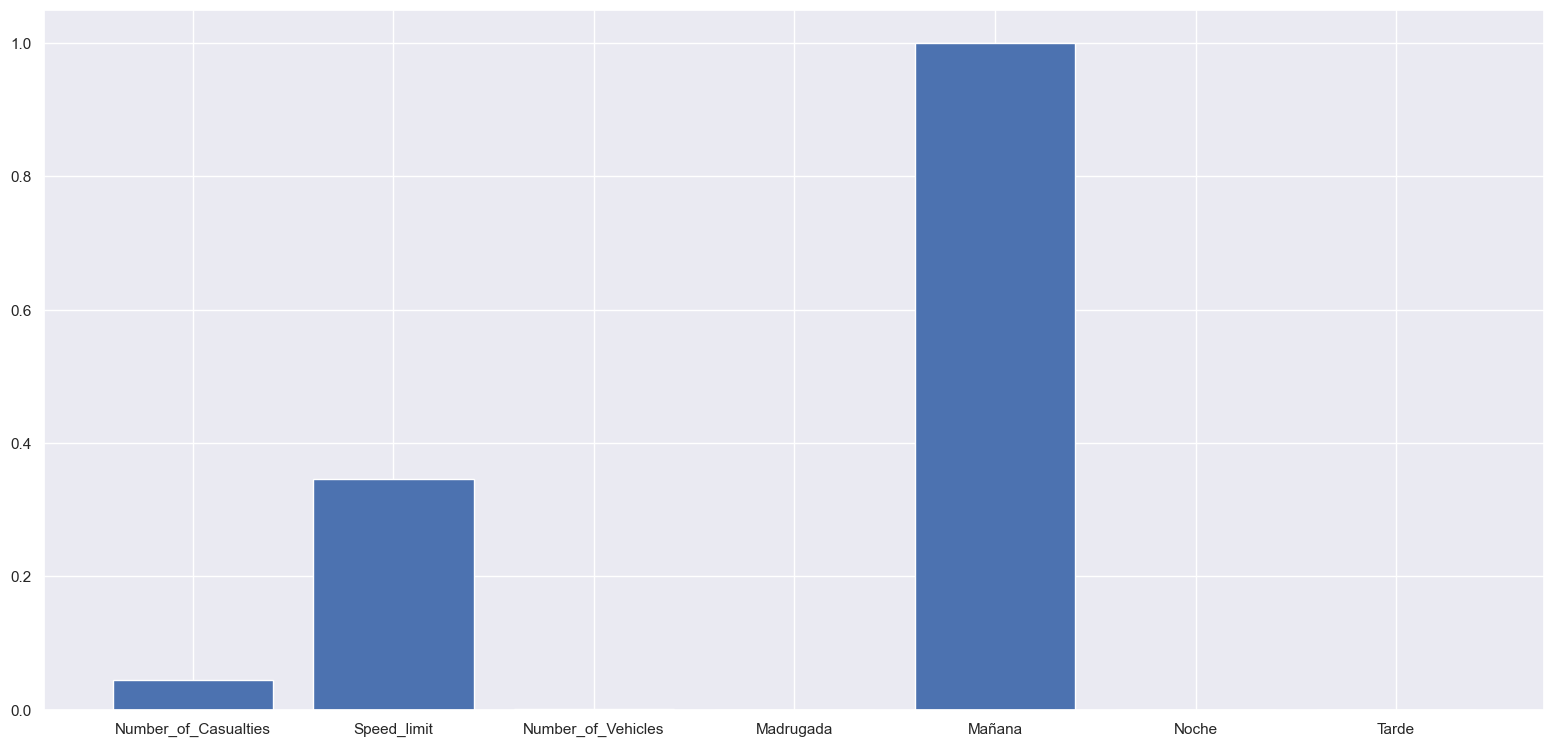

In [66]:
#visualizar los centroides de un cluster. En el ejemplo, el grupo 1. 
fig = plt.figure(figsize=(15, 7))
ax = fig.add_axes([0,0,1,1])
ax.bar(cols_transformed,res_kmeans2.cluster_centers_.tolist()[1])
plt.show()

### 5.5. Evaluar la calidad de los clústeres obtenidos

[0 1 2]


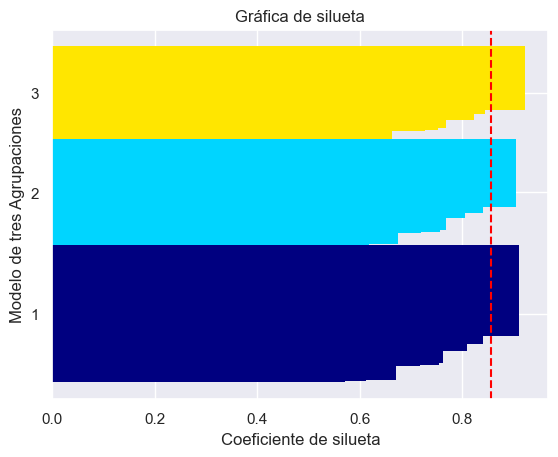

In [67]:
# Esta función puede tardar varios minutos
# Un valor cercano a 1 es un indicador de un bueno modelo. Revisa la teoría para comprender mejor el concepto
plot_silhouette(data = df_bicis_model2_norm[cols_transformed], 
                labels = res_kmeans2.labels_, 
                ylabel = 'Modelo de tres Agrupaciones')

### 5.6 Análisis y conclusiones
<Span style="color:red"> ¿Qué pasó es un mejor modelo, comparado con el primero? ¿Qué nuevas mejoras podemos incorporar para generar un siguiente modelo?
</Span>

A nivel cuantitativo vemos que la silueta es similar a los resutlados de la primera iteración y vemos que hay registros 
más alejados de 1 en los diferentes grupos. Sin embargo, a diferencia de la primera silueta estos registros tienen siluetas superiores a 0.6 en comparación con 0.3 que se identificaron en la iteración 1.

A nivel cualitativo, podemos observar que si bien, los compartamientos en los grupos a nivel de "number of casualities" y "Speed_limit" siguen caracterizando los grupos dados, como información adicional se identifica que en el grupo 1, están los accidentes que ocurren en la tarde, mientras que en el grupo 2, los que ocurren en la mañana.
Con esto presente, se puede hablar con la secretaría de movilidad para que en horarios de tarde o mañana hagan las labores preventivas relacionadas con limite de velocidad correspondiente y en BiciAlpes se generen campañas para consciencitizar a los ciclistas y reducir los accidentes.
Adicionalmente, se puede completar la exploración, revisando estos grupos, a la luz de otras variables no incluídas en el algoritmo de k-means para describirlos mejor y usar los valores no transformados para entender mejor el significado.

## 6. Iteración3. Ejercicio: Nuevo modelo con mejoras a nivel de preparación de datos 

<Span style="color:red"> 
Te proponemos incluir nuevas variables y quitar los valores atípicos e incluir análisis con variables no utilizadas en el algoritmo de kmeans.
</Span>

In [68]:
### 6.1 Identificar las variables a utilizar 
df_bicis_model3 = df_bicis.copy()

### 6.2 Preparación de datos


In [69]:
# Eliminar datos desconocidos, Junction_Detail < 0	 tu puedes hacer algo similar para otras variables
# ¿Cuantas filas se borrarían?

aux_bicis=df_bicis_model3[df_bicis_model3['Junction_Detail'] < 0]


In [70]:
aux_bicis.shape

(25, 15)

### 6.3 Construir el modelo

### 6.4. Visualizar el resultado

### 6.5. Evaluar la calidad de los clústeres obtenidos

### 6.6 Analizar y concluir
<Span style="color:red"> ¿Qué podemos decirle al negocio? ¿Las variables seleccionadas serán las apropiadas?
</Span>